In [27]:
import numpy as np

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"
mask_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/Mounds_raster_mask_opened_closed.npy"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)
mask = np.load(mask_path).astype(np.uint8)

In [28]:
dem_norm = np.zeros_like(dem)

dem_norm[valid] = (dem[valid] - dem[valid].min()) / (dem[valid].max() - dem[valid].min())
dem_norm[~valid] = -1

print(dem.shape)
print(dem_norm.shape)
print(dem_norm.min(), dem_norm.max())
print(dem_norm[valid].min(), dem_norm[valid].max())

(17092, 9791)
(17092, 9791)
-1.0 1.0
0.0 1.0


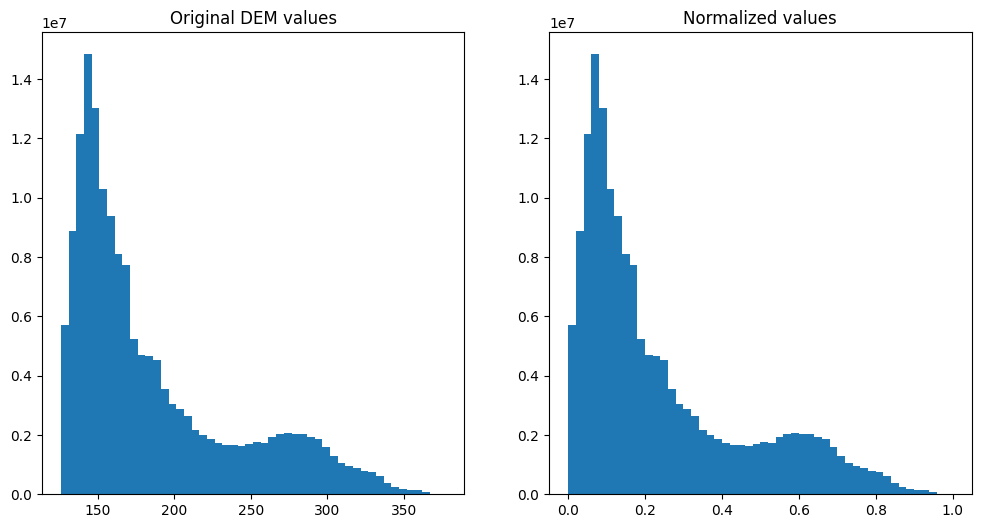

In [29]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.hist(dem[valid].ravel(), bins=50)
plt.title('Original DEM values')
plt.subplot(122)
plt.hist(dem_norm[valid].ravel(), bins=50)
plt.title('Normalized values')
plt.show()

In [31]:
n_samples = dem_norm.shape[0]
train_end = int(n_samples * 0.7)
val_end = train_end + int(n_samples * 0.15)
test_end = train_end + int(n_samples * 0.15)

train_data = dem_norm[:train_end]
val_data = dem_norm[train_end:val_end]
test_data = dem_norm[val_end:]

print(f"Total samples: {n_samples}")
print(f"Training set: {len(train_data)} samples ({len(train_data)/n_samples*100:.1f}%)")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/n_samples*100:.1f}%)")
print(f"Test set: {len(test_data)} samples ({len(test_data)/n_samples*100:.1f}%)")

Total samples: 17092
Training set: 11964 samples (70.0%)
Validation set: 2563 samples (15.0%)
Test set: 2565 samples (15.0%)


In [32]:
to_save={
    "dem": dem_norm,
    "valid": valid
}

np.savez_compressed("../data/processed/DEM_normalized.npz", **to_save)

In [33]:
from scipy.ndimage import distance_transform_edt

distance = distance_transform_edt(1 - mask) * 1

In [34]:
mask_shadowed = np.where(mask == 1, np.ones_like(distance), np.maximum(0, 1 - (distance / 4)))

In [35]:
mask_shadowed[~valid] = 0

In [36]:
np.unique(mask_shadowed)

array([0.        , 0.09861218, 0.20943058, 0.25      , 0.29289322,
       0.44098301, 0.5       , 0.64644661, 0.75      , 1.        ])

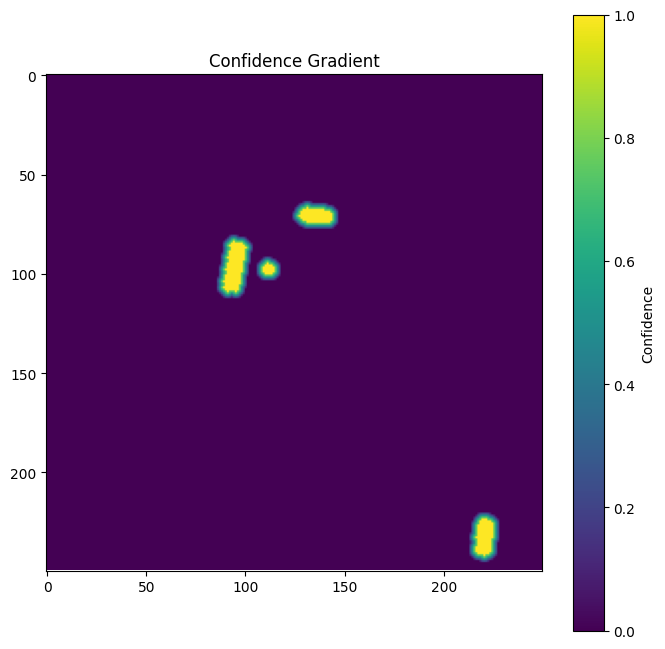

In [37]:
import matplotlib.pyplot as plt
    
patch = mask_shadowed[3000:3250, 3000:3250]
plt.figure(figsize=(8, 8))
plt.imshow(patch, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Confidence')
plt.title('Confidence Gradient')
plt.show()

In [38]:
np.save(
    "../data/processed/mounds_mask_shadowed.npy", 
    mask_shadowed
)